In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

## Download and preparing the Data

In [2]:
data_root = "https://github.com/ageron/data/raw/main/"
lifesat=pd.read_csv(data_root + "lifesat/lifesat.csv")
x=lifesat[["GDP per capita (USD)"]].values      #single [] returns a Series, double "[[]]" returns a DataFrame
y=lifesat[["Life satisfaction"]].values

The Data

In [3]:
lifesat

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6
5,Portugal,32181.154537,5.4
6,Poland,32238.157259,6.1
7,Estonia,35638.421351,5.7
8,Spain,36215.447591,6.3
9,Slovenia,36547.738956,5.9


## Visualising the data

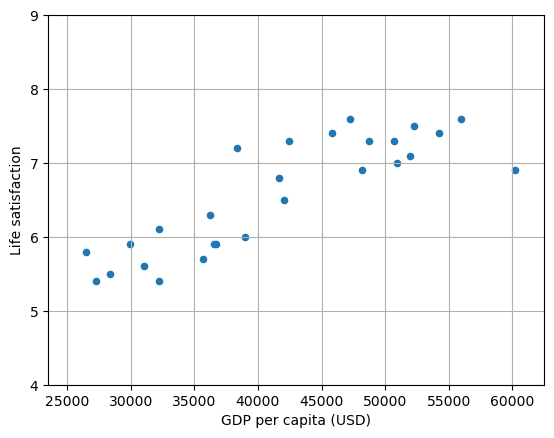

In [4]:
lifesat.plot(kind='scatter', grid=True, x="GDP per capita (USD)", y="Life satisfaction")    #Pandas is actually calling Matplotlib behind the scenes.
# plt.scatter( x, y)
# plt.xlabel("GDP per capita (USD)")
# plt.ylabel("Life satisfaction")
# plt.grid(True)
plt.axis([23500,62500,4,9])
plt.show()

## Selecting a linear model

In [5]:
model = LinearRegression()

## Training the model

In [6]:
#The model looks at all the (x, y) pairs and finds the best line:

#Life satisfaction = a × GDP + b

model.fit(x,y)      #After fit(), the model has learned these values.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### SLOPE and INTERCEPT

In [7]:
print(model.coef_)      # slope
print(model.intercept_) # intercept 

[[6.77889969e-05]]
[3.74904943]


Make a prediction for Cyprus(37655.2)

In [8]:
X_new=[[37655.2]]  #Why double brackets?   Because the model expects: (samples, features) shape, and we have 1 sample and 1 feature.
print(model.predict(X_new)) # output: [[6.30165767]]
                            #model.predict(X_new)  The model substitutes 37655.2 into the learned equation: Life satisfaction = a × GDP + b, 
                            # and returns the predicted life satisfaction.
                            #The reason the output is [[6.30165767]] instead of just 6.30165767 
                            # is because the model returns a 2D array (even for a single prediction) to maintain consistency 
                            # with the expected output shape, which is (samples, targets). In this case, we have 1 sample and 1 target, 
                            # so the output is a 2D array with one row and one column.

[[6.30165767]]


## Graph

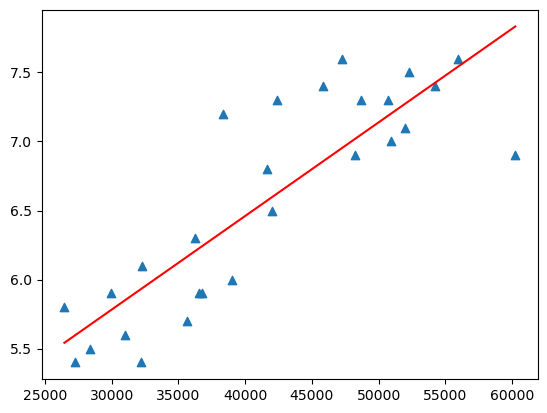

In [9]:
plt.plot(x, model.predict(x), "r-") # plot the regression line
plt.scatter(x, y, marker="^") # plot the original data points
plt.show()